In [11]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from torchdiffeq import odeint
from torchcfm.optimal_transport import wasserstein

In [13]:
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

In [14]:
device = 'cuda:3'

In [15]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
timepoint_key = 'timepoint_tx_days'

n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [16]:
coords = adata.obsm[cellstate_key]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm[f"{cellstate_key}_standardized"] = coords

In [17]:
test_clones = ['Clone_3869' , 'Clone_2673' , 'Clone_2831']
cbs = [adata.obs.query("`timepoint_tx_days` == @t & `clones` in @test_clones").index.to_list()
            for t in adata.uns['pop']['t']]
overlapped_cb_indexs = [[np.where(adata.obs_names == cb)[0] for cb in cb_t] for cb_t in cbs]

In [18]:
test_X = [adata[cb].obsm[cellstate_key][:,:n_dimension].copy() for cb in cbs]

for X in test_X:
    print(X.shape)

(4, 5)
(65, 5)
(187, 5)


In [19]:
adata

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'palantir_pseudotime', 'palantir_entropy'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'X_diffmap', 'X_pca', 'X_umap', 'palantir_fate_probabilities', 'DM_EigenVectors_multiscaled_standardized'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

# compute w2 distance

In [144]:
traj_lookup = {}

['MIO-flow', 'Prescient', 'PINN(ours)', 'SF2M', 'OT-cfm,', 'TrajectoryNet', 'TIGON']

traj_lookup['TrajectoryNet'] = np.load("logs/TrajectoryNet/DM_multiscaled_with_growth/wasstein_trajectories_2d0-3d5.npy")
traj_lookup['Prescient'] = np.load("logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2/wasserstein_simulated_trajectory.npy")
traj_lookup['MIO-flow'] = np.load("results/MIOFlow/klein_subset_DM_EigenVectors_multiscaled/wasserstein_trajectory.npy")

traj_lookup['PINN(ours)'] = np.load("results/wasserstein_PINN_traj.npy")
traj_lookup['TIGON'] = np.load("results/wasserstein_TIGON_traj.npy")
traj_lookup['OT-cfm'] = np.load("results/wasserstein_OTcfm_traj.npy")
traj_lookup['SF2M'] = np.load("results/wasserstein_SF2M_traj.npy")

for k, v in traj_lookup.items():
    print(k, v.shape)

TrajectoryNet (86, 65, 5)
Prescient (21, 65, 5)
MIO-flow (100, 65, 5)
PINN(ours) (11, 65, 5)
TIGON (200, 65, 5)
OT-cfm (200, 65, 5)
SF2M (187, 65, 5)


In [149]:
X_true = test_X[-1]
W2_lookup = {}
for k, v in traj_lookup.items():
    # print(k, v.shape)
    w2 = wasserstein(torch.tensor(v[-1]), torch.tensor(X_true), power=2, method='exact')
    # w2 = wasserstein(torch.tensor(v[-1]), torch.tensor(X_true), power=2, method='sinkhorn', reg=5)
    
    W2_lookup[k] = w2
    print(k, w2)

TrajectoryNet 3.1446460587100473
Prescient 1.5721432083695186
MIO-flow 1.2414935122535928
PINN(ours) 2.144477555413408
TIGON 3.457949849823799
OT-cfm 2.2681509562431956
SF2M 2.1216678961594506


# visualize w2

In [153]:
colors = ["#6F71A3","#7C8DBE","#C5D9ED","#FFE7BD","#F0AD8E","#BA7590","#A1689E"]
order = ['MIO-flow', 'Prescient', 'PINN(ours)', 'SF2M', 'OT-cfm,', 'TrajectoryNet', 'TIGON']
order = ['OT-cfm', 'PINN(ours)', 'SF2M', 'Prescient', 'TrajectoryNet', 'MIO-flow',   'TIGON']
palette = dict(zip(order, colors))

In [154]:
palette

{'OT-cfm': '#6F71A3',
 'PINN(ours)': '#7C8DBE',
 'SF2M': '#C5D9ED',
 'Prescient': '#FFE7BD',
 'TrajectoryNet': '#F0AD8E',
 'MIO-flow': '#BA7590',
 'TIGON': '#A1689E'}

Text(0.5, 0, '')

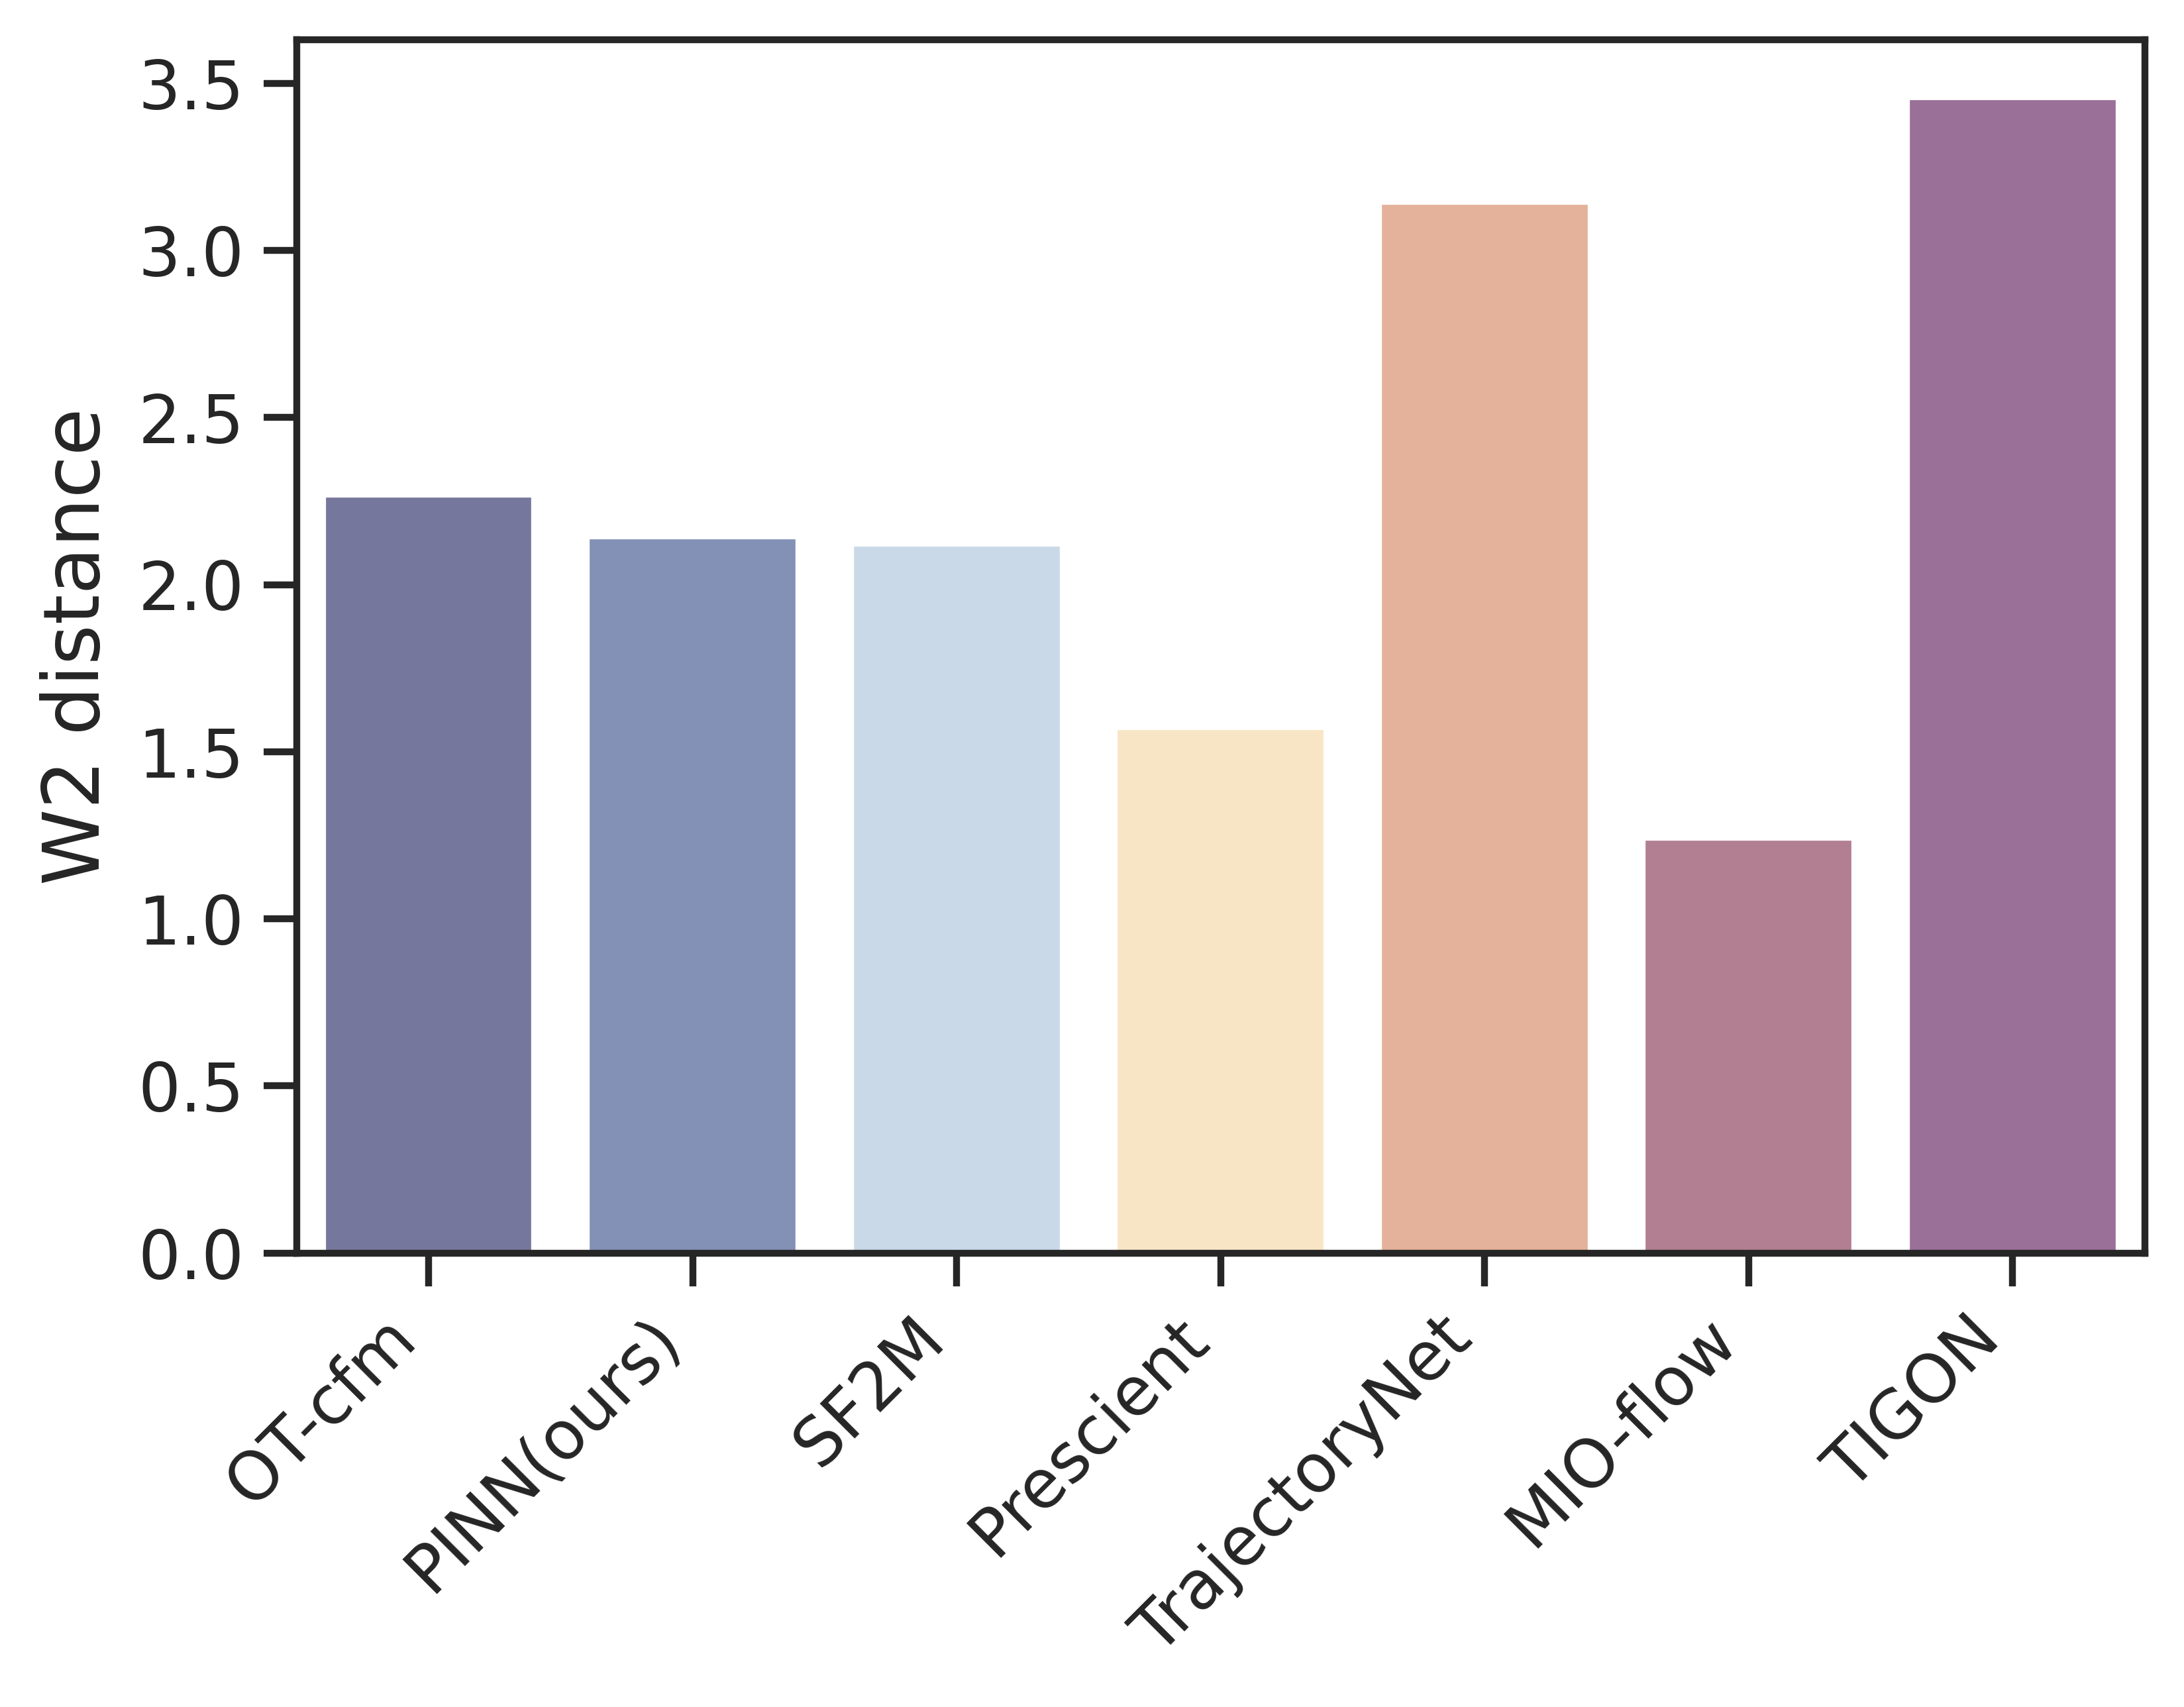

In [161]:
# W2_dict = [{"PINN (ours)": 2.14 , "TIGON":3.45, "OT-cfm": 3.07, "SF2M":2.99}]
W2_df = pd.DataFrame([W2_lookup]).T.reset_index()
W2_df.columns = ['Method', 'W2 distance']

sns.set_theme(style='ticks', font_scale=1.1)
fig = plt.figure(figsize=(6,5), dpi=600, frameon=False)
gs = fig.add_gridspec(5, 1)
axs = fig.add_subplot(gs[:4]) 
sns.barplot(data=W2_df, x='Method', y='W2 distance', ax=axs,hue='Method', 
palette=palette, order=order,
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('W2 distance', fontsize=14)
axs.set_xlabel("")



In [162]:
fig.savefig("figures/Fig3_wasserstein.pdf", format='pdf',transparent=True)

# plot trajectory

In [126]:
def plot_simple_traj(traj, which_dim=[0,1]):    
    n = 2000
    fig = plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.scatter(traj[0, :n, which_dim[0]], traj[0, :n, which_dim[1]], s=13, alpha=0.8, c="black", label=r"$p_0$")
    ax.scatter(traj[:, :n, which_dim[0]], traj[:, :n, which_dim[1]], s=0.2, alpha=0.2, c="olive", label=r"$p_t$")
    ax.scatter(traj[-1, :n, which_dim[0]], traj[-1, :n, which_dim[1]], s=6, alpha=1, c="blue", label= r"$p_1$")
    plt.xticks([])
    plt.yticks([])
    return fig, ax

def plot_allcells_and_trajectories(traj, highlight_idx=range(15), which_dim=[0,1]):
    """Plot trajectories of some selected samples."""

    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.scatter(
        adata.obsm[cellstate_key][:, which_dim[0]],
        adata.obsm[cellstate_key][:, which_dim[1]],
        c=adata.obs[timepoint_key], s=0.4, alpha=0.1,
    )

    ax.scatter(traj[:, :n, which_dim[0]], traj[:, :n, which_dim[1]], s=0.4, alpha=0.1, c="olive", label= r"$p_1$")

    for i in highlight_idx:
        ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], alpha=0.5, c="red" #, label=r"$X_t \mid X_0$"
                )

    return fig, ax

import seaborn as sns
def Deepseak_plot(init_cells, trajs, true_snapshots):

    trajs = np.transpose(trajs, (1,0,2)) # time, cell, dimension

    n_cells = trajs.shape[0]
    # Plotting
    plt.figure(figsize=(6, 6))

    # Plot simulated trajectories
    for i in range(n_cells):
        plt.plot(trajs[i, :, 0], trajs[i, :, 1], 'b-', alpha=0.3, label='Simulated' if i == 0 else "")

    # Plot ground-truth snapshots with KDE contours
    for timepoint, snapshot in true_snapshots.items():
        sns.kdeplot(x=snapshot[:, 0], y=snapshot[:, 1], levels=5, color='r', alpha=0.5, label=f'Ground Truth T{timepoint}' if timepoint == 0 else "")

    # Plot initial cells
    plt.scatter(init_cells[:, 0], init_cells[:, 1], c='k', label='Initial Cells')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Comparison of Simulated Trajectories and Ground-Truth Snapshots')
    plt.legend()
    plt.show()

from matplotlib import cm


colors = cm.viridis([0, 0.5, 1])
popt = ['2','4','6']
palette = dict(zip(popt, colors))

popt = adata.uns['pop']['t'] 
t_list = popt / popt[0]

starting_i = 1
snap_shot = {str(popt[starting_i]): test_X[starting_i]}

def plot_trajectories(snap_shot, traj, pred, which_dim=(0,1), ax=None , density_levels=0.1,dpi=60):
    """
    Plot ground truth snapshots, predicted cells, and simulated trajectories.

    Parameters:
    - snap_shot: dict with time as key and coordinates ndarray as values (Ground Truth).
    - traj: ndarray of shape [n_simulate_time, n_cell, dimension] (Trajectory).
    - pred: dict with time as key and coordinates ndarray as values (Predicted cells).
    """
    if ax is None:
        fig = plt.figure(figsize=(5,4), dpi=dpi)
        ax = fig.gca()

    # Plot simulated trajectories
    n_cells = traj.shape[1]

    for i in range(n_cells):
        ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], 'b-', color='gray', alpha=0.2, label='Simulated Trajectory' if i == 0 else "")

    t0,t1 = pred.keys()

    # Plot ground truth snapshots
    # for time, coords in snap_shot.items():
    #     plt.scatter(coords[:, which_dim[0]], coords[:, which_dim[1]], edgecolors='black', s=60, alpha=0.05, marker='^')
    
    ax.scatter(snap_shot[t1][:, which_dim[0]], snap_shot[t1][:, which_dim[1]], color="#FFE7BD", alpha=0.7, marker='^', s=40, label=f'Ground Truth at Day{t1}')

    sns.kdeplot(x=snap_shot[t1][:, which_dim[0]], y=snap_shot[t1][:, which_dim[1]], levels=density_levels, bw_method=0.1, 
                color='black', alpha=0.2, label=f'Ground Truth Desity', ax=ax)

    # Plot predicted cells

    

    ax.scatter(pred[t1][:, which_dim[0]], pred[t1][:, which_dim[1]], color='black', s=60,  alpha=0.4)
        
    ax.scatter(pred[t0][:, which_dim[0]], pred[t0][:, which_dim[1]], color="#7C8DBE", s=40, alpha=0.7, label=f'Starting cells Day{t0}')
    ax.scatter(pred[t1][:, which_dim[0]], pred[t1][:, which_dim[1]], color=palette[t1], s=40, alpha=0.7, label=f'Predicted cells Day{t1}')

    
    # plt.title('Comparison of Ground Truth, Predicted, and Simulated Trajectories')
    # plt.legend()

    sns.despine(ax=ax)

    return ax

# Example usage
# snap_shot = {0: np.random.rand(10, 2), 50: np.random.rand(10, 2), 99: np.random.rand(10, 2)}
# traj = np.random.rand(100, 10, 2)
# pred = {0: np.random.rand(10, 2), 50: np.random.rand(10, 2), 99: np.random.rand(10, 2)}
# plot_trajectories(snap_shot, traj, pred)

In [127]:

def traject_by_method(method, ax=None):
    
    trajs = traj_lookup[method]
    pred= {'4':trajs[0], '6':trajs[-1]}


    snap_shot = {}
    for starting_i in [1,2]:
        snap_shot = {str(popt[starting_i]): test_X[starting_i]}

    ax = plot_trajectories(snap_shot, trajs, pred, 
                which_dim=[0,2], 
                density_levels=[0.2,0.4,0.6,0.8, 1],
                dpi=60, ax=ax
                )
    
    return ax

In [128]:
traj_lookup.keys()

dict_keys(['TrajectoryNet', 'PRESCIENT', 'MIOFlow', 'PINN', 'TIGON', 'OTCFM', 'SF2M'])

/tmp/ipykernel_720470/4055542355.py:87: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], 'b-', color='gray', alpha=0.2, label='Simulated Trajectory' if i == 0 else "")
/tmp/ipykernel_720470/4055542355.py:87: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], 'b-', color='gray', alpha=0.2, label='Simulated Trajectory' if i == 0 else "")
/tmp/ipykernel_720470/4055542355.py:87: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], 'b-', color='gray', alpha=0.2, label='Simulated Trajectory' if i 

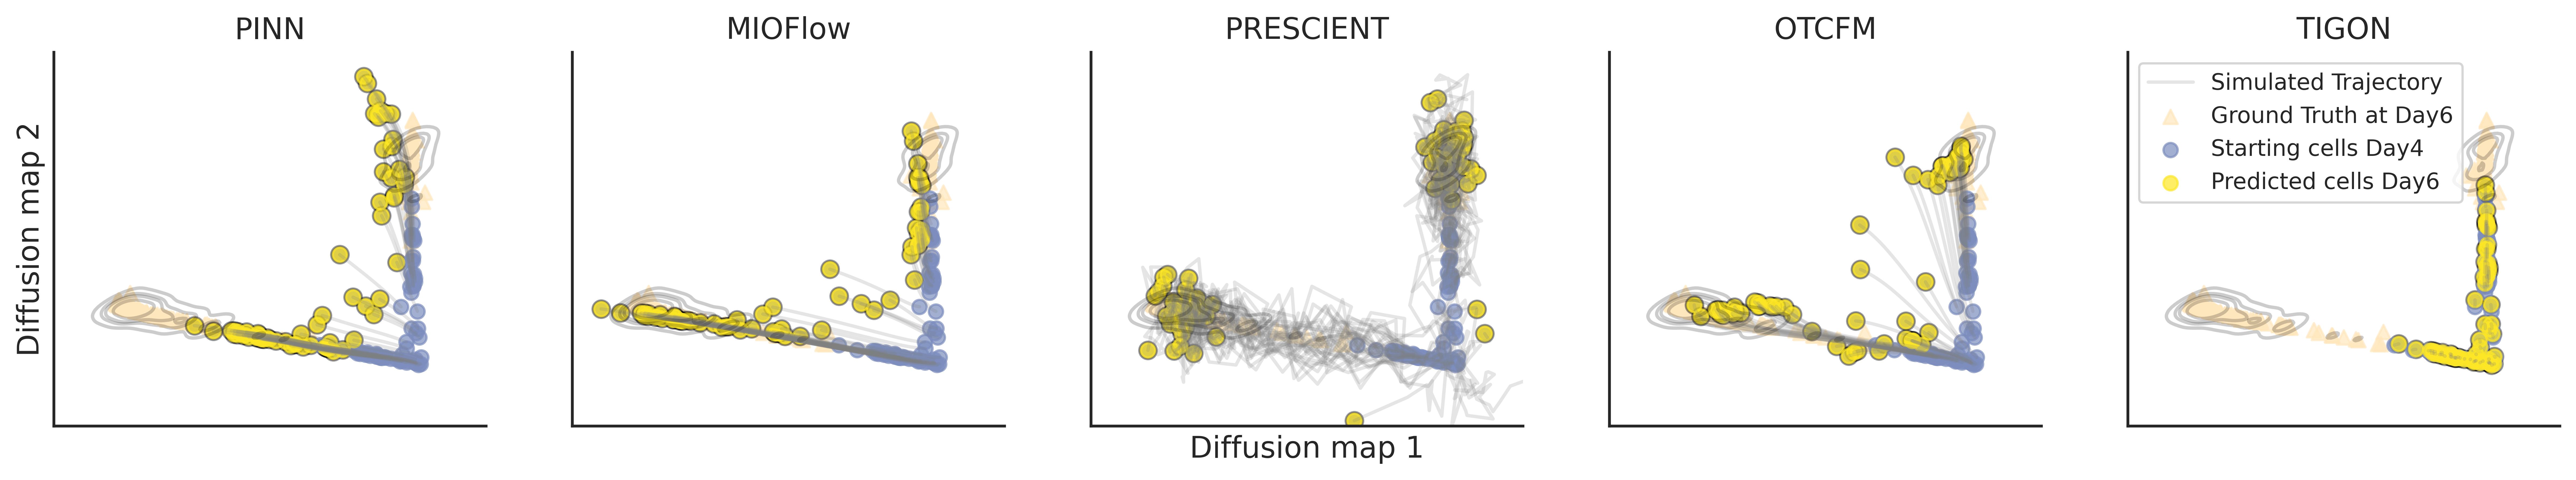

In [ ]:
fig, axs = plt.subplots(1,5, figsize=(20,3.), dpi=600, frameon=False,  sharey=True)

for i, method in enumerate(['PINN', 'MIOFlow', 'PRESCIENT', 'OTCFM', 'TIGON']):
    
    ax = traject_by_method(method, ax = axs[i])

    ax.set_ylim(-0.8,2.4)
    ax.set_xlim(-5.2,0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(method)


axs[0].set_ylabel('Diffusion map 2')
# axs[0].set_xlabel('Diffusion map 1')
axs[2].set_xlabel('Diffusion map 1')
ax.legend(fontsize=10)

In [ ]:
fig.savefig("figures/Fig3_wasserstein_cell.pdf", format='pdf', transparent=True)